# Imports and config


In [14]:
import re
from collections import Counter

import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import ParameterGrid, train_test_split
from torch.nn.utils.rnn import pack_padded_sequence, pad_sequence
from torch.utils.data import DataLoader, Dataset

# Data Loading


In [2]:
df = pd.read_csv("imdb.csv")
print(df.head())

                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


In [3]:
# Remove HTML tags from reviews
df["review"] = df["review"].str.replace(r"<[^>]+>", "", regex=True)

# Map sentiment strings to integers
df["sentiment"] = df["sentiment"].map({"positive": 1, "negative": 0})

In [4]:
train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df["sentiment"]
)
train_df, val_df = train_test_split(
    train_df, test_size=0.2, random_state=42, stratify=train_df["sentiment"]
)

# Data Exploration


In [5]:
print(train_df["sentiment"].value_counts())

sentiment
0    16000
1    16000
Name: count, dtype: int64


# RNNs


## Tokenizer and vocabulary


In [6]:
class TextDataFrameDataset(Dataset):
    def __init__(self, dataframe):
        self.dataframe = dataframe

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):  # ty:ignore[invalid-method-override]
        row = self.dataframe.iloc[idx]
        return row["sentiment"], row["review"]


def tokenize(text):
    text = str(text).lower()
    text = re.sub(r'([.?!,\'"])', r" \1 ", text)
    return text.split()


class Vocab:
    def __init__(self, text_iterable, min_freq=1):
        self.stoi = {"<unk>": 0, "<pad>": 1}
        self.unk_idx = 0
        self.pad_idx = 1

        counter = Counter()
        for text in text_iterable:
            counter.update(tokenize(text))

        idx = 2
        for word, freq in counter.items():
            if freq >= min_freq:
                self.stoi[word] = idx
                idx += 1

    def __call__(self, tokens):
        return [self.stoi.get(token, self.unk_idx) for token in tokens]

    def __len__(self):
        return len(self.stoi)


def create_collate_fn(vocab):
    def collate_batch(batch):
        label_list, text_list, lengths_list = [], [], []

        for label, text in batch:
            label_list.append(label)
            tokens = vocab(tokenize(text))
            processed_text = torch.tensor(tokens, dtype=torch.int64)
            text_list.append(processed_text)
            lengths_list.append(len(tokens))

        labels = torch.tensor(label_list, dtype=torch.float32)
        lengths = torch.tensor(lengths_list, dtype=torch.int64)

        padded_texts = pad_sequence(
            text_list, batch_first=True, padding_value=vocab.pad_idx
        )

        return labels, padded_texts, lengths

    return collate_batch

In [7]:
vocab = Vocab(train_df["review"], min_freq=1)

train_dataset = TextDataFrameDataset(train_df)
val_dataset = TextDataFrameDataset(val_df)
test_dataset = TextDataFrameDataset(test_df)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    collate_fn=create_collate_fn(vocab),
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    collate_fn=create_collate_fn(vocab),
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    collate_fn=create_collate_fn(vocab),
)

## LSTM and GRU


In [8]:
class ClassicLSTM(nn.Module):
    def __init__(self, n_layers, vocab_size, embed_dim, hidden_dim, pad_idx):
        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size, embed_dim, padding_idx=pad_idx
        )
        self.lstm = nn.LSTM(
            embed_dim, hidden_dim, num_layers=n_layers, batch_first=True
        )
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, text, lengths):
        embedded = self.embedding(text)

        packed_embedded = pack_padded_sequence(
            embedded, lengths.cpu(), batch_first=True, enforce_sorted=False
        )

        packed_output, (h_n, c_n) = self.lstm(packed_embedded)

        final_hidden_state = h_n[-1]

        return self.fc(final_hidden_state).squeeze()


In [9]:
class ClassicGRU(nn.Module):
    def __init__(self, n_layers, vocab_size, embed_dim, hidden_dim, pad_idx):
        super().__init__()
        self.embedding = nn.Embedding(
            vocab_size, embed_dim, padding_idx=pad_idx
        )
        self.gru = nn.GRU(
            embed_dim, hidden_dim, num_layers=n_layers, batch_first=True
        )
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, text, lengths):
        embedded = self.embedding(text)

        packed_embedded = pack_padded_sequence(
            embedded, lengths.cpu(), batch_first=True, enforce_sorted=False
        )

        packed_output, h_n = self.gru(packed_embedded)

        final_hidden_state = h_n[-1]
        return self.fc(final_hidden_state).squeeze()


In [ ]:
def train(model, title, epochs=5):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Training on: {device}")

    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    criterion = nn.BCEWithLogitsLoss()
    criterion = criterion.to(device)

    def binary_accuracy(preds, y):
        rounded_preds = torch.round(torch.sigmoid(preds))
        correct = (rounded_preds == y).float()
        return correct.sum() / len(correct)

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
    }

    for epoch in range(epochs):
        epoch_train_loss = 0
        epoch_train_acc = 0

        model.train()

        for batch_labels, batch_texts, batch_lengths in train_loader:
            batch_labels = batch_labels.to(device)
            batch_texts = batch_texts.to(device)

            optimizer.zero_grad()
            predictions = model(batch_texts, batch_lengths)

            loss = criterion(predictions, batch_labels)
            acc = binary_accuracy(predictions, batch_labels)

            loss.backward()
            optimizer.step()

            epoch_train_loss += loss.item()
            epoch_train_acc += acc.item()

        epoch_val_loss = 0
        epoch_val_acc = 0

        model.eval()

        with torch.no_grad():
            for batch_labels, batch_texts, batch_lengths in val_loader:
                batch_labels = batch_labels.to(device)
                batch_texts = batch_texts.to(device)

                predictions = model(batch_texts, batch_lengths)

                loss = criterion(predictions, batch_labels)
                acc = binary_accuracy(predictions, batch_labels)

                epoch_val_loss += loss.item()
                epoch_val_acc += acc.item()

        avg_train_loss = epoch_train_loss / len(train_loader)
        avg_train_acc = epoch_train_acc / len(train_loader)

        avg_val_loss = epoch_val_loss / len(val_loader)
        avg_val_acc = epoch_val_acc / len(val_loader)

        history["train_loss"].append(avg_train_loss)
        history["train_acc"].append(avg_train_acc)
        history["val_loss"].append(avg_val_loss)
        history["val_acc"].append(avg_val_acc)

        print(
            f"Epoch: {epoch + 1:02} | "
            f"Train Loss: {avg_train_loss:.4f} | Train Acc: {avg_train_acc * 100:.2f}% | "
            f"Val Loss: {avg_val_loss:.4f} | Val Acc: {avg_val_acc * 100:.2f}%"
        )

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    fig.suptitle(title)
    axes[0].plot(history["train_loss"], label="Training")
    axes[0].plot(history["val_loss"], label="Validation", linestyle="--")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Error")
    axes[0].legend()

    axes[1].plot(history["train_acc"], label="Training")
    axes[1].plot(history["val_acc"], label="Validation", linestyle="--")
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy (%)")
    axes[1].legend()

    plt.tight_layout()
    plt.show()
    plt.close(fig)

    return model, history


Training on: cuda
Epoch: 01 | Train Loss: 0.6018 | Train Acc: 65.94% | Val Loss: 0.3962 | Val Acc: 82.73%
Epoch: 02 | Train Loss: 0.3044 | Train Acc: 87.37% | Val Loss: 0.2672 | Val Acc: 89.40%
Epoch: 03 | Train Loss: 0.1757 | Train Acc: 93.54% | Val Loss: 0.2647 | Val Acc: 89.66%
Epoch: 04 | Train Loss: 0.1094 | Train Acc: 96.16% | Val Loss: 0.3068 | Val Acc: 89.70%
Epoch: 05 | Train Loss: 0.0582 | Train Acc: 98.30% | Val Loss: 0.3272 | Val Acc: 89.76%


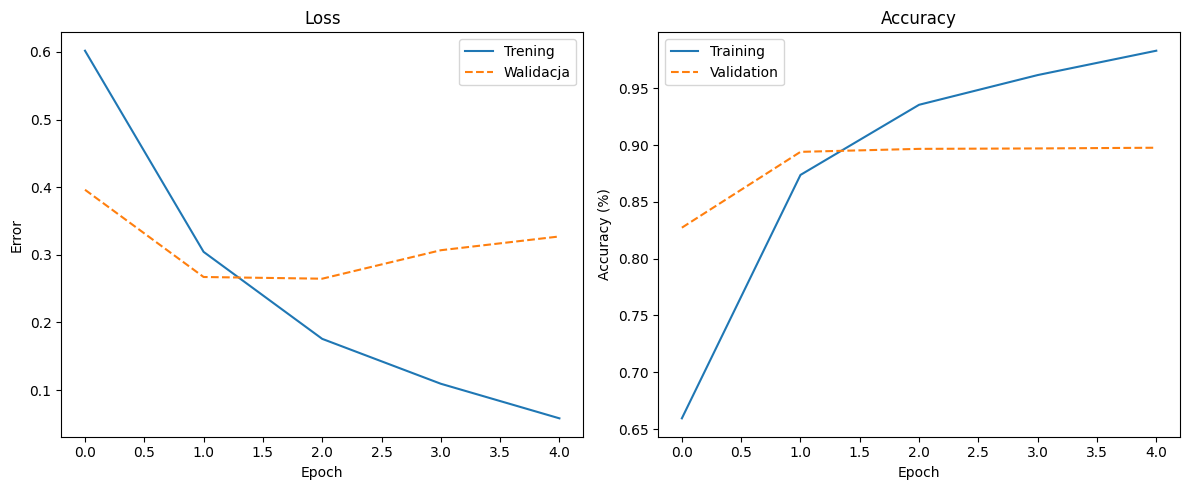

Training on: cuda
Epoch: 01 | Train Loss: 0.5994 | Train Acc: 63.28% | Val Loss: 0.3323 | Val Acc: 85.76%
Epoch: 02 | Train Loss: 0.2585 | Train Acc: 89.58% | Val Loss: 0.2471 | Val Acc: 90.22%
Epoch: 03 | Train Loss: 0.1490 | Train Acc: 94.67% | Val Loss: 0.2585 | Val Acc: 90.34%
Epoch: 04 | Train Loss: 0.0818 | Train Acc: 97.39% | Val Loss: 0.2832 | Val Acc: 90.05%
Epoch: 05 | Train Loss: 0.0391 | Train Acc: 99.00% | Val Loss: 0.3881 | Val Acc: 90.21%


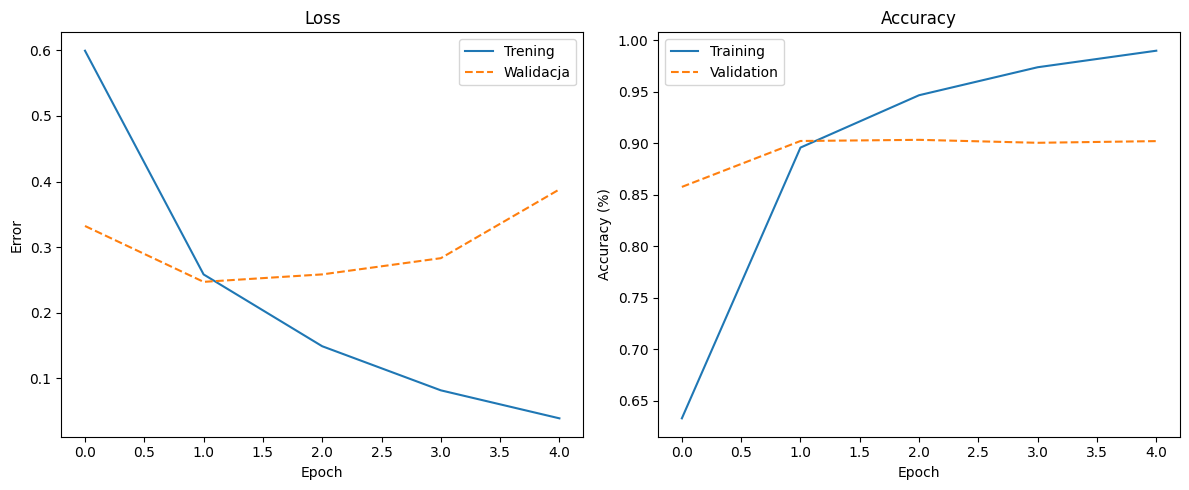

(ClassicGRU(
   (embedding): Embedding(144887, 100, padding_idx=1)
   (gru): GRU(100, 256, num_layers=2, batch_first=True)
   (fc): Linear(in_features=256, out_features=1, bias=True)
 ),
 {'train_loss': [0.5994325391277671,
   0.2584602902419865,
   0.14902724143490195,
   0.08182303053792567,
   0.0391324099439662],
  'train_acc': [0.63275, 0.89584375, 0.94671875, 0.97390625, 0.98996875],
  'val_loss': [0.33229448103904724,
   0.24714804834127427,
   0.2585270126909018,
   0.2832178819477558,
   0.38810125569440423],
  'val_acc': [0.857625, 0.90225, 0.903375, 0.9005, 0.902125]})

In [ ]:
INPUT_DIM = len(vocab)
EMBED_DIM = 100
HIDDEN_DIM = 256
N_LAYERS = 2
PAD_IDX = vocab.pad_idx
model = ClassicLSTM(N_LAYERS, INPUT_DIM, EMBED_DIM, HIDDEN_DIM, PAD_IDX)
train(model, "LSTM")

INPUT_DIM = len(vocab)
EMBED_DIM = 100
HIDDEN_DIM = 256
N_LAYERS = 2
PAD_IDX = vocab.pad_idx
model2 = ClassicGRU(N_LAYERS, INPUT_DIM, EMBED_DIM, HIDDEN_DIM, PAD_IDX)
train(model2, "GRU")


## LSTM with hidden state pooling


In [18]:
class PoolingLSTM(nn.Module):
    def __init__(
        self,
        vocab_size,
        embed_dim,
        hidden_dim,
        n_layers,
        bidirectional,
        dropout,
        pad_idx,
    ):
        super().__init__()
        self.pad_idx = pad_idx

        self.embedding = nn.Embedding(
            vocab_size, embed_dim, padding_idx=pad_idx
        )

        self.lstm = nn.LSTM(
            embed_dim,
            hidden_dim,
            num_layers=n_layers,
            bidirectional=bidirectional,
            dropout=dropout if n_layers > 1 else 0,
            batch_first=True,
        )

        fc_input_dim = hidden_dim * 2 if bidirectional else hidden_dim
        self.fc = nn.Linear(fc_input_dim, 1)

    def forward(self, text, lengths):
        mask = (text != self.pad_idx).float().unsqueeze(-1)

        embedded = self.embedding(text)

        output, _ = self.lstm(embedded)

        masked_output = output * mask

        summed_states = torch.sum(masked_output, dim=1)

        real_lengths = lengths.to(summed_states.device).float().view(-1, 1)
        mean_pooled = summed_states / real_lengths

        return self.fc(mean_pooled).squeeze()


### Hyperparameter tuning


Training hidden state pooling LSTM with params: {'bidirectional': True, 'embed_dim': 50, 'hidden_dim': 200, 'n_layers': 1}
Training on: cuda
Epoch: 01 | Train Loss: 0.4726 | Train Acc: 77.01% | Val Loss: 0.3497 | Val Acc: 85.32%
Epoch: 02 | Train Loss: 0.2629 | Train Acc: 89.61% | Val Loss: 0.2888 | Val Acc: 88.41%


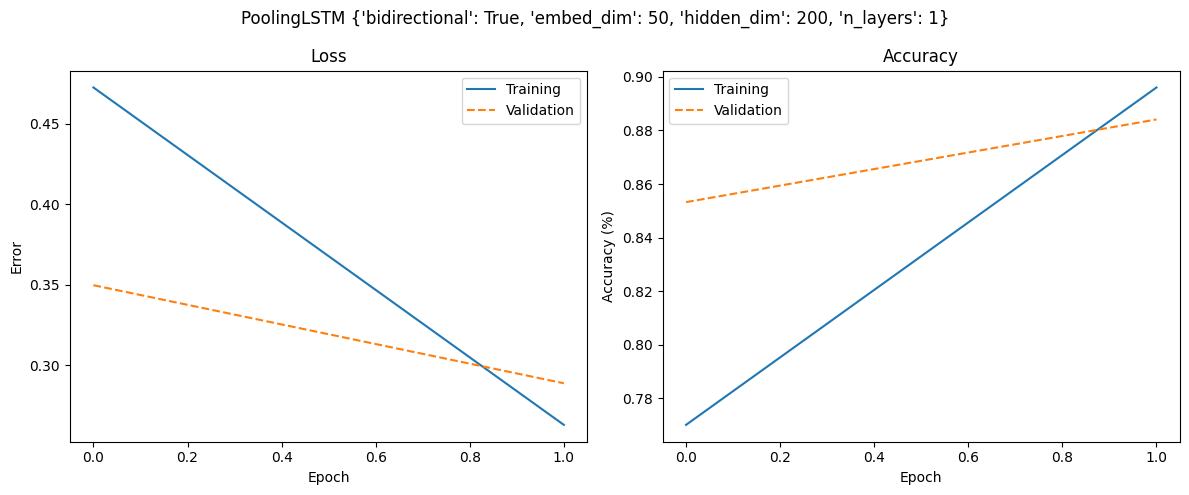

Training hidden state pooling LSTM with params: {'bidirectional': True, 'embed_dim': 50, 'hidden_dim': 200, 'n_layers': 2}
Training on: cuda
Epoch: 01 | Train Loss: 0.4417 | Train Acc: 78.95% | Val Loss: 0.3456 | Val Acc: 85.01%
Epoch: 02 | Train Loss: 0.2476 | Train Acc: 90.31% | Val Loss: 0.2765 | Val Acc: 88.99%


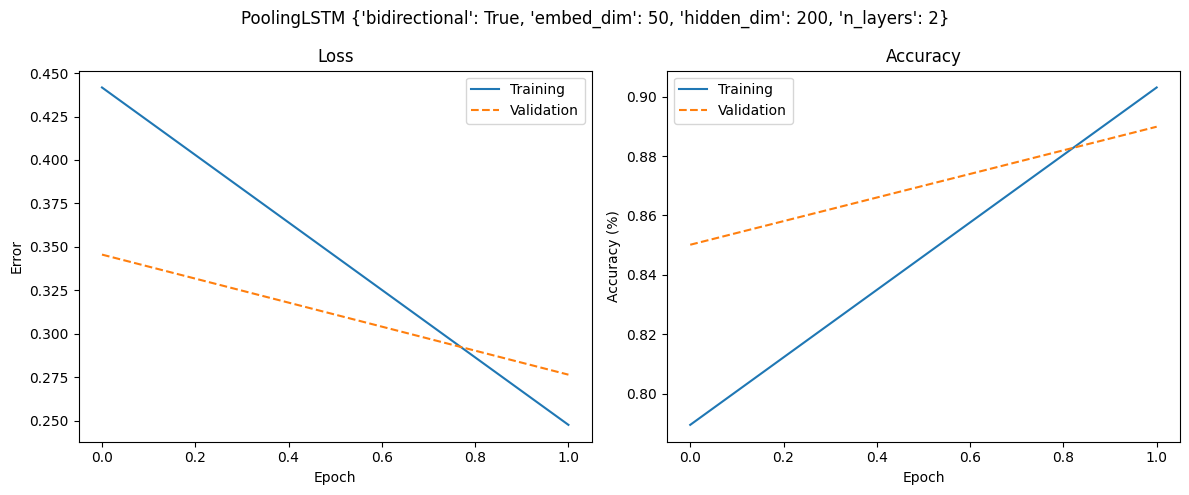

Training hidden state pooling LSTM with params: {'bidirectional': True, 'embed_dim': 50, 'hidden_dim': 200, 'n_layers': 3}
Training on: cuda
Epoch: 01 | Train Loss: 0.4651 | Train Acc: 77.02% | Val Loss: 0.3335 | Val Acc: 86.50%
Epoch: 02 | Train Loss: 0.2601 | Train Acc: 89.72% | Val Loss: 0.2942 | Val Acc: 88.72%


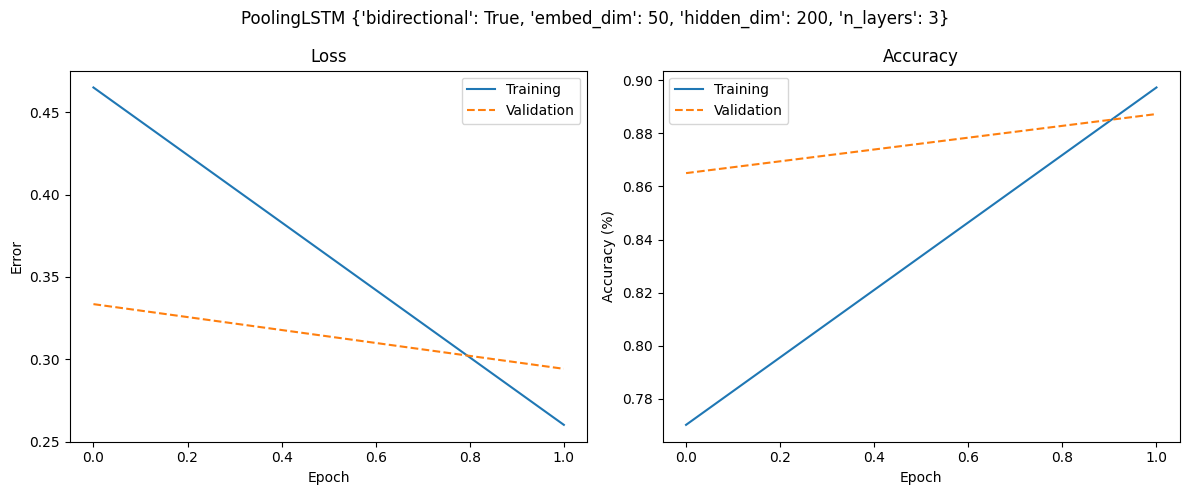

Training hidden state pooling LSTM with params: {'bidirectional': True, 'embed_dim': 50, 'hidden_dim': 300, 'n_layers': 1}
Training on: cuda
Epoch: 01 | Train Loss: 0.4585 | Train Acc: 78.03% | Val Loss: 0.3598 | Val Acc: 84.90%
Epoch: 02 | Train Loss: 0.2544 | Train Acc: 90.03% | Val Loss: 0.2908 | Val Acc: 88.02%


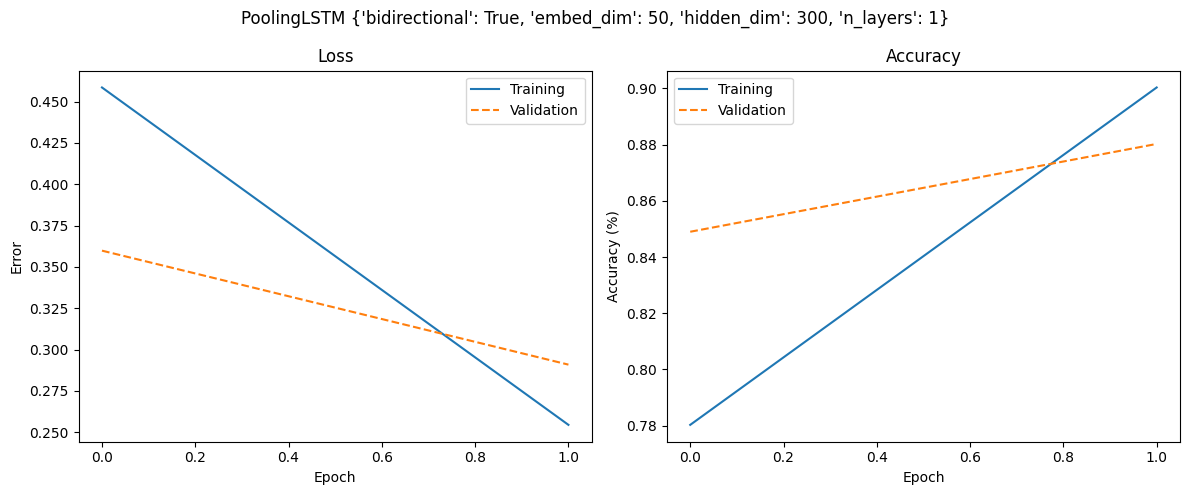

Training hidden state pooling LSTM with params: {'bidirectional': True, 'embed_dim': 50, 'hidden_dim': 300, 'n_layers': 2}
Training on: cuda


In [ ]:
param_grid = {
    "n_layers": [1, 2, 3],
    "bidirectional": [True, False],
    "embed_dim": [50, 150],
    "hidden_dim": [200, 300],
}

for params in ParameterGrid(param_grid):
    print(f"Training hidden state pooling LSTM with params: {params}")

    model = PoolingLSTM(
        vocab_size=len(vocab),
        dropout=0.25,
        pad_idx=vocab.pad_idx,
        **params,
    )

    train(model, f"PoolingLSTM {params}", epochs=2)


# BERT Fine-tuning
